In [ ]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import pandas as pd
from pathlib import Path
import nibabel as nib
from nilearn.plotting import plot_stat_map, show
import nibabel as nib
from nilearn.image import load_img
from atlas_methods import create_atlas_target, add_lat_target
from cidp_methods import extract_integer
import pickle
import sys
sys.path.append("/sc-projects/sc-proj-cc15-cn-ukbiobank/analyses/brain-xai-benchmark/4-xai_validation")
from metrics import get_relevance_mass_accuracy_batch

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
# ukbb field id for cIDP to visualize
field = 26544

# min and max pc for plotting
min_pc_plot = 0
max_pc_plot = 50

# include border voxels in visualization
dilation_iter = 2

if field > 27000:
    # cortical target
    atlas_id = "aparc2009"
    # config csv
    config_csv_path = "/sc-projects/sc-proj-cc15-cn-ukbiobank/analyses/brain-xai-benchmark/idp_correction/setup_files/config_csvs/config_cortical.csv"
    # prev. computed corrected target and pval-maps for voxel-corrected-target correlation
    result_dir = "/sc-projects/sc-proj-cc15-cn-ukbiobank/analyses/Explanation-benchmark-paper/results/target_generation/aparc_int_downsample_200perm_5kimgs"
else:
    # subcortical target
    atlas_id = "aseg"
    config_csv_path = "/sc-projects/sc-proj-cc15-cn-ukbiobank/analyses/brain-xai-benchmark/idp_correction/setup_files/config_csvs/config_subcortical.csv"
    result_dir = "/sc-projects/sc-proj-cc15-cn-ukbiobank/analyses/Explanation-benchmark-paper/results/target_generation/aseg_int_downsample_200perm_5kimgs"

# bg img for visualization
img_bg_path = "/sc-projects/sc-proj-cc15-cn-ukbiobank/analyses/brain-xai-benchmark/files/mni_templates/MNI152_T1_2mm_brain.nii.gz"

masker_path = "/sc-projects/sc-proj-cc15-cn-ukbiobank/analyses/brain-xai-benchmark/files/brain_masker/10k_brain_masker.pkl"

In [15]:
# load stuff
bg_img = load_img(img_bg_path)
bg_img = nib.Nifti1Image(bg_img.get_fdata(), np.eye(4))
config_df = pd.read_csv(config_csv_path, header=None, names=["id", "field", "atlas_key", "name"])

with open(masker_path, 'rb') as file:
    nifti_masker = pickle.load(file)

Mean intensity of Putamen (left hemisphere)


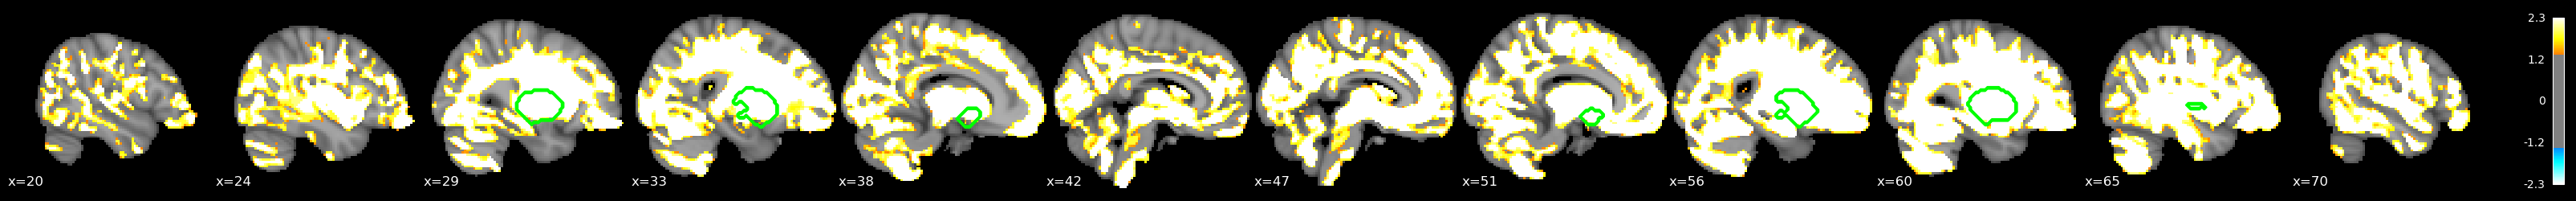

max_pc: 1
% of significant association in ROI: 0.03353182598948479


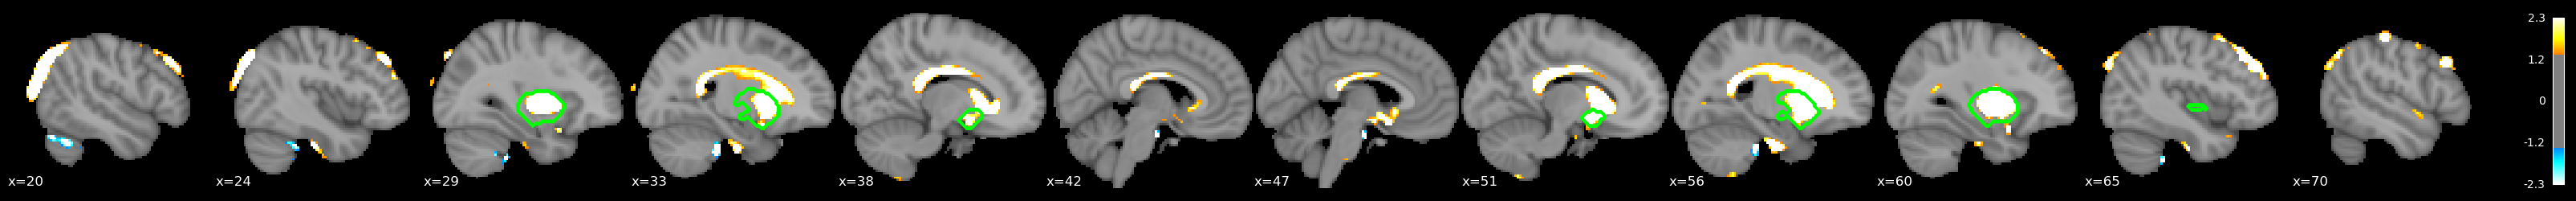

max_pc: 6
% of significant association in ROI: 0.18483448028564453


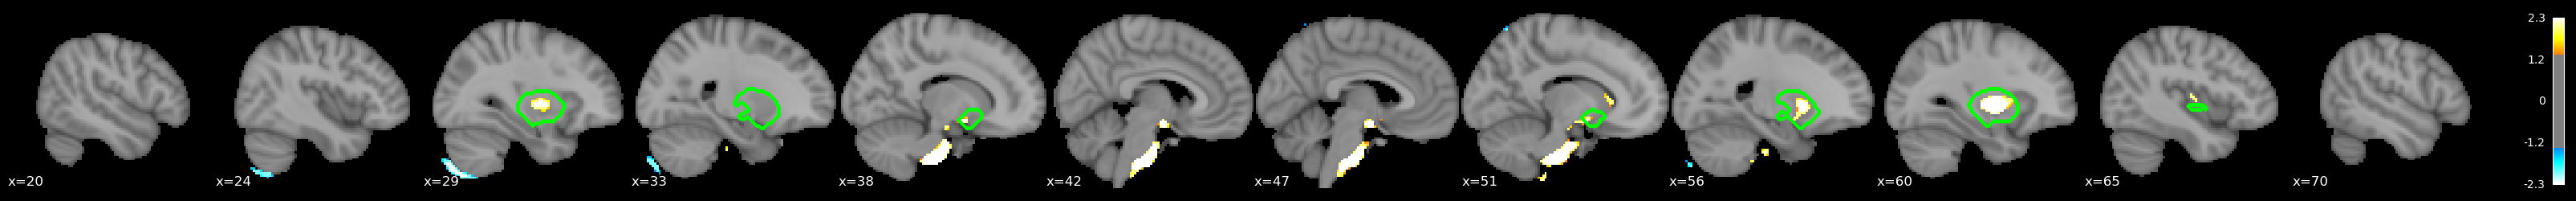

max_pc: 11
% of significant association in ROI: 0.2219618409872055


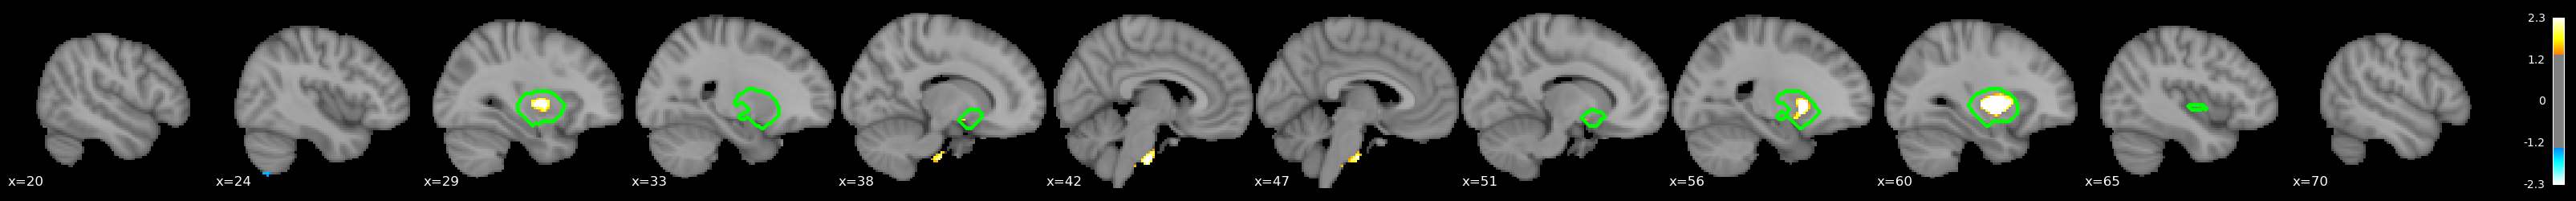

max_pc: 16
% of significant association in ROI: 0.6832627058029175


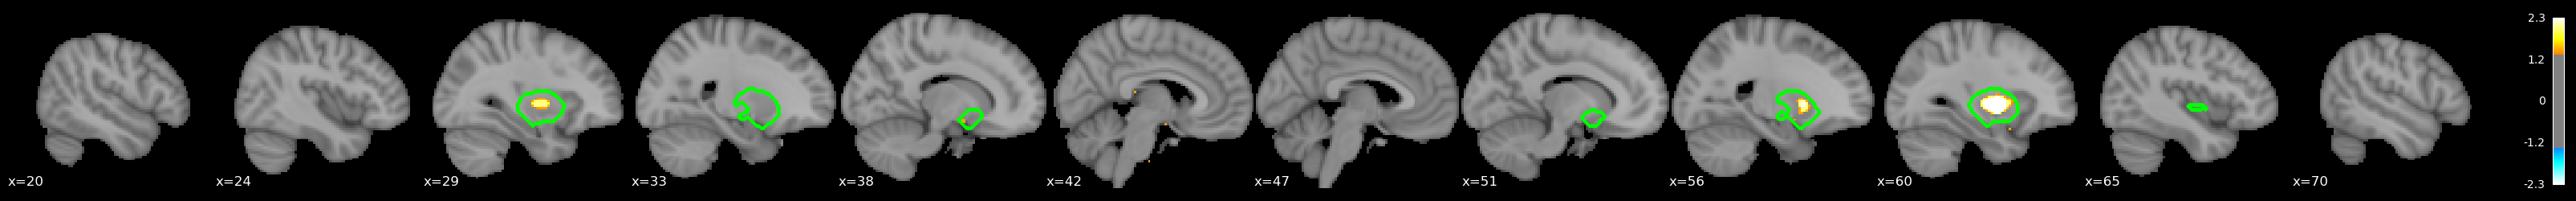

max_pc: 21
% of significant association in ROI: 0.9597069621086121


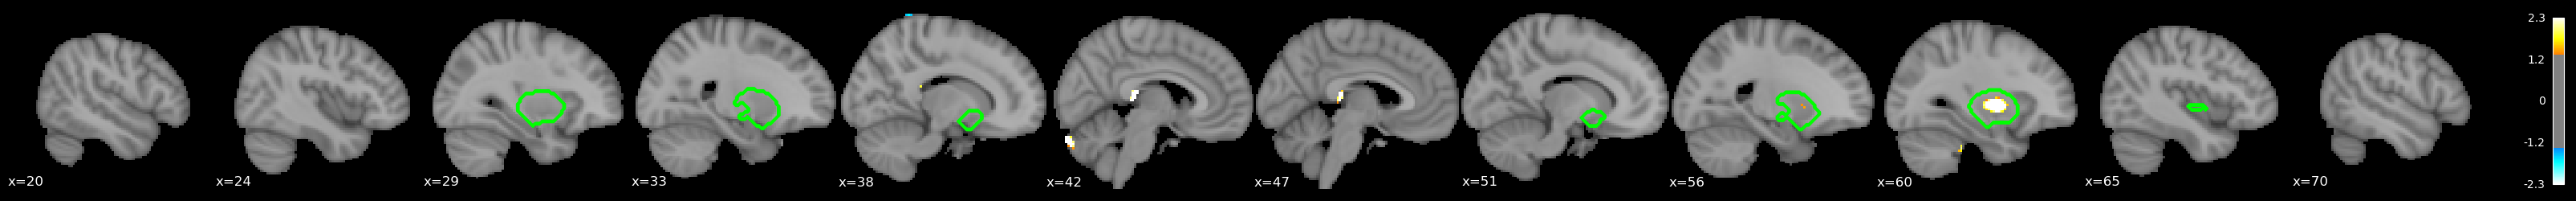

max_pc: 26
% of significant association in ROI: 0.47826087474823


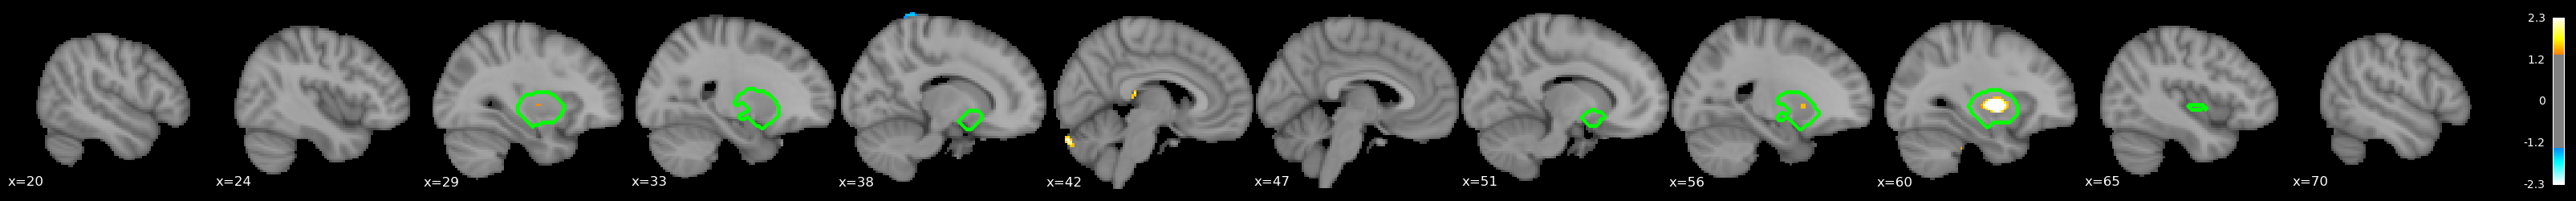

max_pc: 31
% of significant association in ROI: 0.6472019553184509


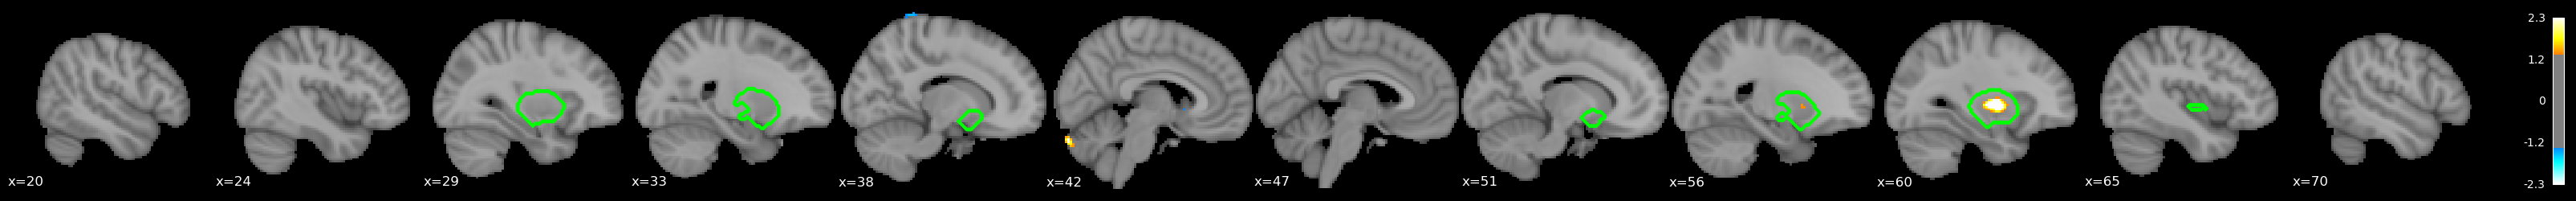

max_pc: 36
% of significant association in ROI: 0.708737850189209


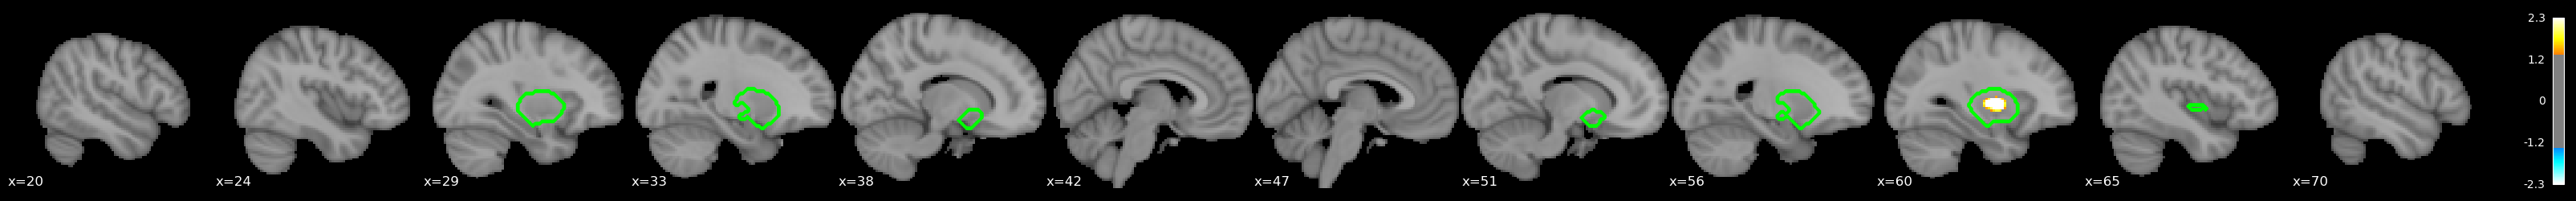

max_pc: 41
% of significant association in ROI: 1.0


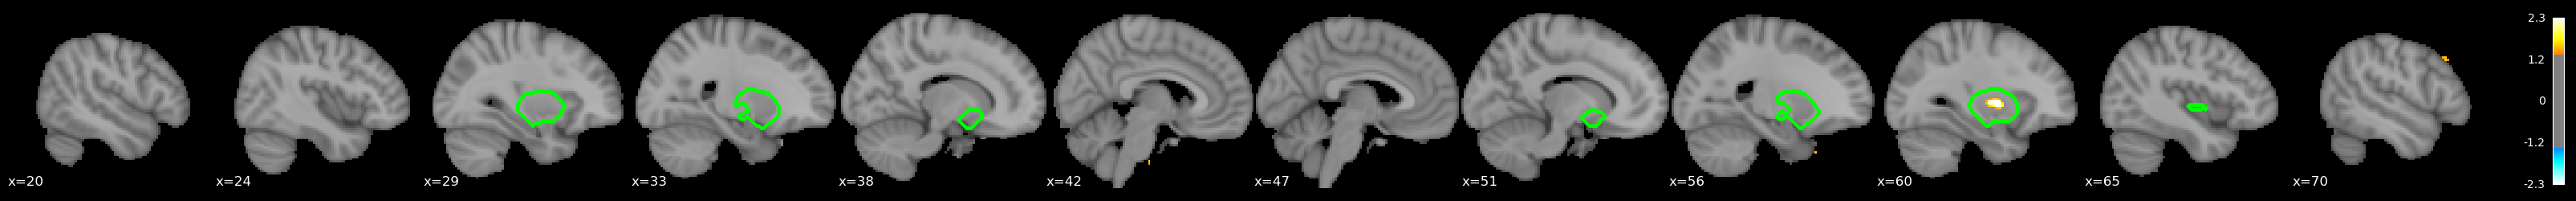

max_pc: 46
% of significant association in ROI: 0.6666666865348816


In [16]:
full_field = f"f.{field}.2.0"
field_dir = f"{result_dir}/{full_field}/"

## get atlas for target field
atlas_key = int(config_df[config_df["field"] == field]["atlas_key"].iloc[0])
print(config_df[config_df["field"] == field]["name"].iloc[0])

# get atlas targets for visualization
atlas = create_atlas_target(atlas_key, atlas_id, dilation_iter=dilation_iter)
atlas_target = add_lat_target(config_df, field, atlas_id, atlas, dilation_iter = dilation_iter)

p = Path(field_dir)

for sub_file in sorted(p.iterdir(), key=extract_integer):
    file_name = sub_file.name
    if "p_vals" in file_name:
        max_pc = file_name.split("_")[2].split(".")[0]
        
        if int(max_pc) > min_pc_plot and int(max_pc) < max_pc_plot:
            
            p_vals = np.load(sub_file)

            p_vals_image = nib.Nifti1Image(p_vals, np.eye(4))

            cut_coords = np.linspace(20, 70, num=12, dtype="int16")
            display = plot_stat_map(
            p_vals_image,
            bg_img=bg_img,
            display_mode="x",
            cut_coords=cut_coords,
            threshold=1.3, # equals alpha = 0.05
            )

            display.add_contours(nib.Nifti1Image(np.float32(atlas_target), np.eye(4)), colors="lime")
            show()

            # clip p_values based on significance threshold
            p_vals = np.abs(p_vals)
            p_vals[p_vals < 1.3] = 0
            p_vals[p_vals >= 1.3] = 1

            # get % of significant association in ROI
            p_vals_transformed = nifti_masker.transform(nib.Nifti1Image(np.float32(p_vals.squeeze()), np.eye(4)))
            atlas_transformed = nifti_masker.transform(nib.Nifti1Image(np.float32(atlas_target), np.eye(4)))

            score = get_relevance_mass_accuracy_batch(p_vals_transformed, atlas_transformed)[0]
            print(f"max_pc: {max_pc}")
            print(f"% of significant association in ROI: {score}")